<a href="https://colab.research.google.com/github/MananKulshrestha/cred_card_fraud_detection/blob/main/smote%26undersampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle
from google.colab import files

# 1. Upload the kaggle.json file you downloaded
print("Please upload your kaggle.json file:")
files.upload()

# 2. Move it to the right directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the credit card fraud dataset directly
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q creditcardfraud.zip
print("Dataset downloaded and unzipped! You can now run the rest of your code.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 328MB/s]

Dataset downloaded and unzipped! You can now run the rest of your code.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. Load and Clean Data
df = pd.read_csv('creditcard.csv')

print("\n*** Data Preprocessing: SMOTE + Undersampling ***")

if 'Amount' in df.columns and 'Time' in df.columns:
    scaler = StandardScaler()
    df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
    df['Time_Scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
    df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# 2. PROPER SPLIT: Create Train, Validation, and Test sets FIRST
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# ---------------------------------------------------------
# USER DEFINED RATIOS
# ---------------------------------------------------------
# 1. How much of the dataset should be Fraud AFTER SMOTE?
smote_fraud_percentage = 0.1  # Example: 0.05 means boost Fraud to 5% of the data

# 2. How much of the dataset should be Normal (Non-Fraud) AFTER Undersampling?
final_non_fraud_percentage = 0.75  # Example: 0.80 means cut Normal cases down until they are 80% (leaving Fraud at 20%)
# ---------------------------------------------------------

print(f"Original training distribution: {Counter(y_train)}")

# Get current counts
counts = Counter(y_train)
normal_count = counts[0]
fraud_count = counts[1]

# --- STEP 1: SMOTE (Increase Fraud) ---
# Calculate exact number of fraud rows needed to hit your smote_fraud_percentage
target_fraud_count = int(normal_count * (smote_fraud_percentage / (1 - smote_fraud_percentage)))

# Ensure we only oversample (never accidentally undersample if percentage is set too low)
target_fraud_count = max(fraud_count, target_fraud_count)

smote = SMOTE(sampling_strategy={1: target_fraud_count}, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribution after SMOTE: {Counter(y_train_smote)}")

# --- STEP 2: RANDOM UNDERSAMPLING (Decrease Normal) ---
# Calculate exact number of normal rows needed to hit your final_non_fraud_percentage
target_normal_count = int(target_fraud_count * (final_non_fraud_percentage / (1 - final_non_fraud_percentage)))

# Ensure we only undersample (never ask for more normal rows than we currently have)
target_normal_count = min(normal_count, target_normal_count)

rus = RandomUnderSampler(sampling_strategy={0: target_normal_count}, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_smote, y_train_smote)

print(f"Final distribution after Undersampling: {Counter(y_train_res)}")

# Overwrite X_train and y_train so models run seamlessly
X_train = X_train_res
y_train = y_train_res

# 3. Recalculate Class Weights for the final training data
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"\nFinal Class Weights for Models:")
print(f"Class 0 (Normal): {class_weights[0]:.4f}")
print(f"Class 1 (Fraud): {class_weights[1]:.4f}")
print(f"\nValidation set distribution (Untouched): {Counter(y_val)}")


*** Data Preprocessing: SMOTE + Undersampling ***
Original training distribution: Counter({0: 170588, 1: 295})
Distribution after SMOTE: Counter({0: 170588, 1: 18954})
Final distribution after Undersampling: Counter({0: 56862, 1: 18954})

Final Class Weights for Models:
Class 0 (Normal): 0.6667
Class 1 (Fraud): 2.0000

Validation set distribution (Untouched): Counter({0: 56863, 1: 99})


In [25]:
# ---------------------------------------------------------
# Setup: Metrics and Callbacks
# ---------------------------------------------------------
# Wrapping metrics in a function ensures each model gets a fresh, isolated set of metrics
def get_metrics():
    return [
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]

# The EarlyStopping callback allows the model to revert to its best epoch
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    patience=5,                 # Wait 5 epochs after seeing no improvement before stopping
    restore_best_weights=True,  # "Fall down" to the best epoch's weights
    verbose=1
)

# ---------------------------------------------------------
# Model 1: Sigmoid Categorical Model (Logistic Regression)
# ---------------------------------------------------------
print("\n--- Training Model 1: Sigmoid Baseline ---")
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

model_sigmoid.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=get_metrics())

# Epochs doubled from 10 to 20
history_sig = model_sigmoid.fit(X_train, y_train,
                                batch_size=2048,
                                epochs=20,
                                validation_data=(X_val, y_val), # <--- ADD THIS
                                class_weight=class_weights,
                                callbacks=[early_stopping],
                                verbose=1)




--- Training Model 1: Sigmoid Baseline ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5633 - auc: 0.6803 - loss: 0.9070 - precision: 0.3284 - recall: 0.7147 - val_accuracy: 0.5214 - val_auc: 0.7645 - val_loss: 0.9129 - val_precision: 0.0030 - val_recall: 0.8182
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6066 - auc: 0.8106 - loss: 0.7219 - precision: 0.3729 - recall: 0.8419 - val_accuracy: 0.5367 - val_auc: 0.8211 - val_loss: 0.8758 - val_precision: 0.0032 - val_recall: 0.8485
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6268 - auc: 0.8564 - loss: 0.6330 - precision: 0.3901 - recall: 0.8749 - val_accuracy: 0.5514 - val_auc: 0.8465 - val_loss: 0.8415 - val_precision: 0.0033 - val_recall: 0.8586
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6431 - auc: 0.8820 - loss: 0.5670 - precision: 0.4035 - recall: 0.8936 - val_accuracy: 0.5666 - val_auc: 0.8639 - val_loss: 0.8094 - val_precision: 0.0035 - val_recall: 0.8788
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

In [43]:
# ---------------------------------------------------------
# Model 2: Basic Neural Network (2 Hidden Layers)
# ---------------------------------------------------------
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    patience=15,                # Wait 10 epochs after seeing no improvement before stopping
    restore_best_weights=True,  # "Fall down" to the best epoch's weights
    verbose=1
)
print("\n--- Training Model 2: Basic Neural Network ---")
model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=get_metrics())

# Epochs doubled from 15 to 30
history_nn = model_nn.fit(X_train, y_train,
                          batch_size=2048,
                          epochs=65,
                          validation_split=0.2,
                          class_weight=class_weights,
                          callbacks=[early_stopping], # Added callback
                          verbose=1)




--- Training Model 2: Basic Neural Network ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/65
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8759 - auc: 0.4562 - loss: 0.5448 - precision: 0.1752 - recall: 0.2660 - val_accuracy: 0.6382 - val_auc: 0.0000e+00 - val_loss: 0.6115 - val_precision: 1.0000 - val_recall: 0.6382
Epoch 2/65
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9335 - auc: 0.8321 - loss: 0.2965 - precision: 0.4742 - recall: 0.5873 - val_accuracy: 0.8560 - val_auc: 0.0000e+00 - val_loss: 0.3764 - val_precision: 1.0000 - val_recall: 0.8560
Epoch 3/65
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9587 - auc: 0.8999 - loss: 0.2163 - precision: 0.6577 - recall: 0.7058 - val_accuracy: 0.8704 - val_auc: 0.0000e+00 - val_loss: 0.2903 - val_precision: 1.0000 - val_recall: 0.8704
Epoch 4/65
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9686 - auc: 0.9311 - loss: 0.1667 - precision: 0.7476 - recall: 0.7512 - val_accuracy: 0.8806 - val_auc: 0.0000e+00 - val_loss: 0.2560 - val_precision: 1.0000 - val_recall: 0.8806
Epoch 5/65
30/30 ━━━

In [46]:
# ---------------------------------------------------------
# Model 3: Deeper Neural Network (3 Hidden Layers)
# ---------------------------------------------------------

print("\n--- Training Model 3: Deeper Neural Network ---")
model_nn_deep = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    # NEW: Third hidden layer continuing the funnel structure
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_nn_deep.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=get_metrics())

history_nn_deep = model_nn_deep.fit(X_train, y_train,
                                    batch_size=2048,
                                    epochs=40,
                                    validation_split=0.2,
                                    class_weight=class_weights,
                                    verbose=1)




--- Training Model 3: Deeper Neural Network ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7875 - auc: 0.1771 - loss: 0.7099 - precision: 0.0149 - recall: 0.0369 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 1.1715 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9011 - auc: 0.3741 - loss: 0.4939 - precision: 0.0388 - recall: 0.0245 - val_accuracy: 0.0040 - val_auc: 0.0000e+00 - val_loss: 0.9101 - val_precision: 1.0000 - val_recall: 0.0040
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9297 - auc: 0.6254 - loss: 0.4024 - precision: 0.3436 - recall: 0.1380 - val_accuracy: 0.3280 - val_auc: 0.0000e+00 - val_loss: 0.7683 - val_precision: 1.0000 - val_recall: 0.3280
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9452 - auc: 0.8000 - loss: 0.3248 - precision: 0.6065 - recall: 0.3517 - val_accuracy: 0.7219 - val_auc: 0.0000e+00 - val_loss: 0.6206 - val_precision: 1.0000 - val_recall: 0.7219
Epoch 5/40


--- Evaluation on Test Data ---

1. Sigmoid Model Results:
  loss: 0.4446
  compile_metrics: 0.8603

2. Basic NN (2 Layers) Results:
  loss: 0.0169
  compile_metrics: 0.9960

3. Deeper NN (3 Layers) Results:
  loss: 0.0162
  compile_metrics: 0.9945


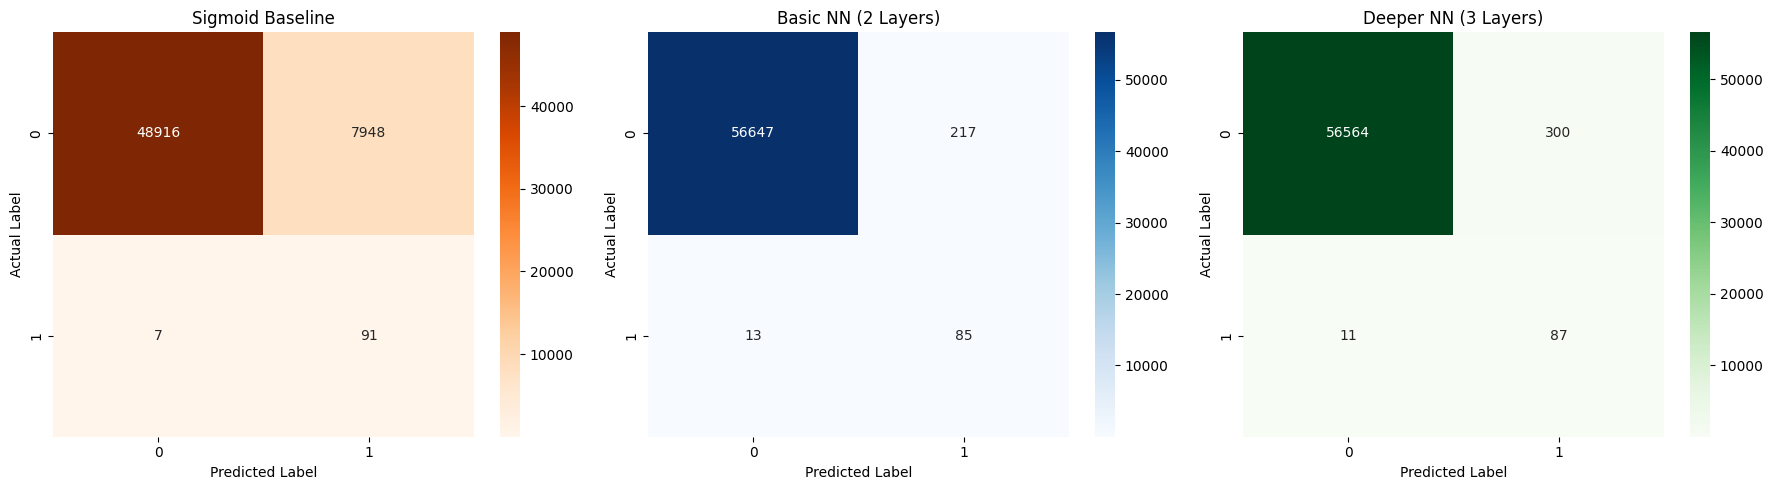

In [47]:
# ---------------------------------------------------------
# 5. Evaluation & Comparison
# ---------------------------------------------------------
print("\n--- Evaluation on Test Data ---")

print("\n1. Sigmoid Model Results:")
sig_results = model_sigmoid.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model_sigmoid.metrics_names, sig_results):
    print(f"  {name}: {value:.4f}")

print("\n2. Basic NN (2 Layers) Results:")
nn_results = model_nn.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model_nn.metrics_names, nn_results):
    print(f"  {name}: {value:.4f}")

print("\n3. Deeper NN (3 Layers) Results:")
nn_deep_results = model_nn_deep.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model_nn_deep.metrics_names, nn_deep_results):
    print(f"  {name}: {value:.4f}")



# Generate confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sigmoid Baseline Confusion Matrix
sig_predictions = (model_sigmoid.predict(X_test, verbose=0) > 0.5).astype("int32")
sns.heatmap(confusion_matrix(y_test, sig_predictions), annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Sigmoid Baseline')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# 2. Basic NN (2 Layers) Confusion Matrix
nn_predictions = (model_nn.predict(X_test, verbose=0) > 0.5).astype("int32")
sns.heatmap(confusion_matrix(y_test, nn_predictions), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Basic NN (2 Layers)')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

# 3. Deeper NN (3 Layers) Confusion Matrix
nn_deep_predictions = (model_nn_deep.predict(X_test, verbose=0) > 0.5).astype("int32")
sns.heatmap(confusion_matrix(y_test, nn_deep_predictions), annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title('Deeper NN (3 Layers)')
axes[2].set_ylabel('Actual Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


--- Training Model 4: XGBoost ---
Calculated scale_pos_weight: 3.00
Fitting XGBoost model...
[0]	validation_0-auc:0.95369
[36]	validation_0-auc:0.97255

--- Evaluation on Test Data (XGBoost) ---
Accuracy: 0.9879
AUC:      0.9701

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.88      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.93      0.60     56962
weighted avg       1.00      0.99      0.99     56962



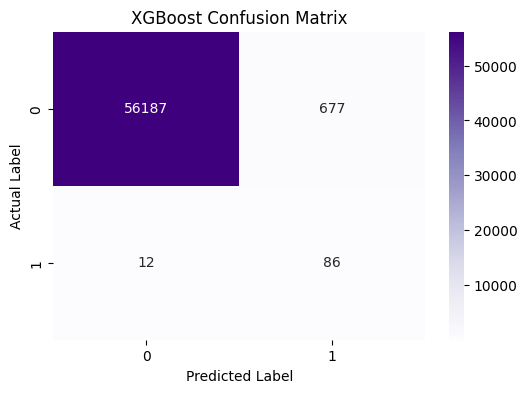

In [50]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print("\n--- Training Model 4: XGBoost ---")

# 1. Calculate scale_pos_weight for severe imbalance
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_weight = neg_count / pos_count if pos_count > 0 else 1.0

print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

# 2. Initialize the XGBoost Classifier
# MOVED early_stopping_rounds HERE for newer XGBoost versions
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_weight,
    eval_metric='auc',
    early_stopping_rounds=20,   # <--- Moved here
    random_state=42
)

# 3. Train the model
# The eval_set still stays here so the model has data to check for early stopping
print("Fitting XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# 4. Evaluation on Test Data
print("\n--- Evaluation on Test Data (XGBoost) ---")
# Get hard predictions (0 or 1)
xgb_predictions = xgb_model.predict(X_test)
# Get probabilities for the positive class (used for AUC)
xgb_predict_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate and print metrics
accuracy = accuracy_score(y_test, xgb_predictions)
auc_score = roc_auc_score(y_test, xgb_predict_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC:      {auc_score:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, xgb_predictions))

# 5. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_predictions), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()